In [2]:

import numpy as np
import matplotlib.pyplot as plt
import h5py
import hdf5plugin
from tqdm.notebook import tqdm
from scipy.ndimage import median_filter, center_of_mass

In [3]:
%matplotlib widget

In [4]:
data_path = "/Users/lvmeizhong/Desktop/denoise/17944364/000278.h5"

In [5]:
datah5 = h5py.File(data_path, 'r')
frames = datah5['entry/measurement/eiger500k/frames'][:] # is faster to load the frames like this as a chunk
scan = datah5['entry/description'][:]
print(scan)
datah5.close()

[b'npointflyscan sx 0.5 6.5 120 sy -2 5 140 0.1']


In [6]:
reshape_frames = np.reshape(frames, (141, 121, 512, 1028))

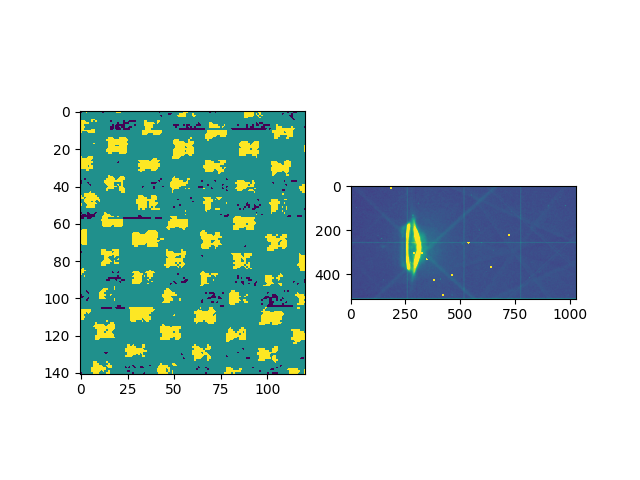

In [7]:
fig, ax = plt.subplots(1, 2)
total_Real = np.sum(reshape_frames, axis = (2, 3))
ax[0].imshow(total_Real, vmax = np.percentile(total_Real, 99))
total_RSM = np.sum(reshape_frames, axis = (0, 1))
ax[1].imshow(total_RSM, vmax = np.percentile(total_RSM, 99))

### Interactive picker (square detector view)

- Left: `total_Real` heatmap (click to select `(iy, ix)`).
- Right: detector image at `(iy, ix)`, displayed as a **512×512 square** (fixed: left 512 columns of the 512×1028 detector).
- `mode`: `single` (one detector frame) or `mean` (scan-grid window average).
- `win`: window radius for `mean` mode (auto-disabled in `single` mode).
- `box`: show/hide the selected window on `total_Real`.


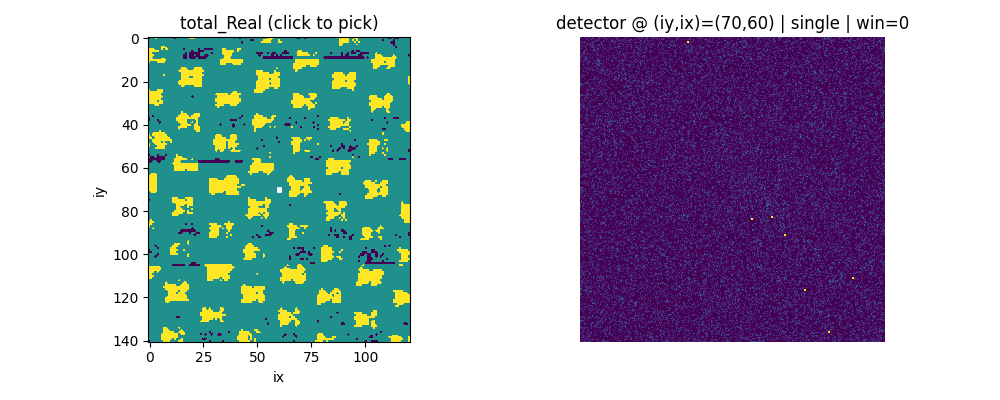

In [13]:
# %matplotlib widget  # Recommended for smooth interactive updates (requires ipympl)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

# ---- required ----
assert "reshape_frames" in globals(), "Missing reshape_frames (H,W,512,1028)"
assert "total_Real" in globals(), "Missing total_Real (H,W)"

H, W = total_Real.shape
detH, detW = reshape_frames.shape[2], reshape_frames.shape[3]
assert detH <= detW, "Expected detector width >= height for square crop."

# ---- widgets ----
iy = widgets.IntSlider(H // 2, 0, H - 1, 1, description="iy", continuous_update=True)
ix = widgets.IntSlider(W // 2, 0, W - 1, 1, description="ix", continuous_update=True)

mode = widgets.Dropdown(
    options=[("single (one detector frame)", "single"),
             ("mean over window (scan-grid)", "mean")],
    value="single", description="mode"
)

win = widgets.IntSlider(2, 0, 10, 1, description="win", continuous_update=True)
show_box = widgets.Checkbox(True, description="box")

# ---- helpers ----
def square_left(img):
    """Always return a square view (detH x detH) using the left detH columns."""
    return np.asarray(img)[:, :detH]

def get_detector(i_y, i_x, w, md):
    """Return detector image: single frame or scan-grid window mean."""
    if md == "single" or w == 0:
        return square_left(reshape_frames[i_y, i_x])
    y0, y1 = max(0, i_y - w), min(H, i_y + w + 1)
    x0, x1 = max(0, i_x - w), min(W, i_x + w + 1)
    return square_left(reshape_frames[y0:y1, x0:x1].mean(axis=(0, 1)))

# ---- figure ----
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax0.imshow(total_Real, vmax=np.percentile(total_Real, 99), origin="upper")
ax0.set_title("total_Real (click to pick)")
ax0.set_xlabel("ix"); ax0.set_ylabel("iy")

rect = patches.Rectangle((0, 0), 1, 1, linewidth=2, edgecolor="w", facecolor="none")
ax0.add_patch(rect)

im1 = ax1.imshow(np.zeros((detH, detH), np.float32), origin="upper")
ax1.set_title("detector (square view)")
ax1.axis("off")

plt.tight_layout()

# ---- update ----
def update(_=None):
    i_y, i_x = iy.value, ix.value
    md = mode.value
    w = win.value if md == "mean" else 0

    if show_box.value:
        rect.set_visible(True)
        rect.set_xy((i_x - w - 0.5, i_y - w - 0.5))
        rect.set_width(2 * w + 1)
        rect.set_height(2 * w + 1)
    else:
        rect.set_visible(False)

    img = get_detector(i_y, i_x, w, md)
    im1.set_data(img)
    im1.set_clim(float(np.min(img)), float(np.percentile(img, 99.7)))
    ax1.set_title(f"detector @ (iy,ix)=({i_y},{i_x}) | {md} | win={w}")

    fig.canvas.draw_idle()

def on_mode(change):
    if change["new"] == "single":
        win.disabled = True
        win.value = 0
    else:
        win.disabled = False
        if win.value == 0:
            win.value = 2
    update()

mode.observe(on_mode, names="value")
for w in [iy, ix, win, show_box]:
    w.observe(update, names="value")

# ---- click to pick ----
def on_click(event):
    if event.inaxes != ax0 or event.xdata is None or event.ydata is None:
        return
    ix.value = int(np.clip(round(event.xdata), 0, W - 1))
    iy.value = int(np.clip(round(event.ydata), 0, H - 1))

fig.canvas.mpl_connect("button_press_event", on_click)

# ---- UI ----
display(widgets.VBox([
    widgets.HBox([iy, ix]),
    widgets.HBox([mode, win, show_box]),
]))

on_mode({"new": mode.value})
update()
plt.show()


### Interactive picker (total_Real → detector), RAW vs PROCESSED

- Left: `total_Real` heatmap (click to select `(iy, ix)`).
- Right: detector image at that point, shown as a **512×512 square** (fixed: left 512 columns of the 512×1028 detector).
- `mode`: `single` = one frame, `mean(win)` = scan-grid window average (win = 0 or 10).
- `view`: `RAW` vs `PROCESSED` (`BAD->0` and optional `VST: sqrt(max(x,0)+0.375)`).
- `box`: toggle the window overlay on `total_Real`.


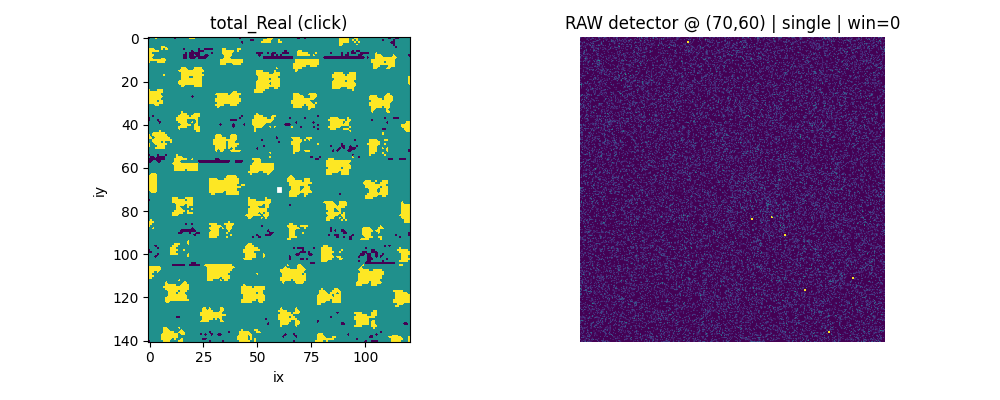

In [12]:
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

# ---- required ----
assert "reshape_frames" in globals(), "Missing reshape_frames (H,W,512,1028)"
assert "total_Real" in globals(), "Missing total_Real (H,W)"

H, W = total_Real.shape
detH, detW = reshape_frames.shape[2], reshape_frames.shape[3]
BAD = float(np.uint32(2**32 - 1))
assert detH <= detW, "Expected detector width >= height."

# ---- widgets (minimal) ----
iy = widgets.IntSlider(H // 2, 0, H - 1, 1, description="iy", continuous_update=True)
ix = widgets.IntSlider(W // 2, 0, W - 1, 1, description="ix", continuous_update=True)

mode = widgets.Dropdown(options=[("single", "single"), ("mean(win)", "mean")],
                        value="single", description="mode")
win = widgets.Dropdown(options=[0, 10], value=0, description="win")  # only for mean
view = widgets.Dropdown(options=[("RAW", "raw"), ("PROCESSED", "proc")],
                        value="raw", description="view")

box = widgets.Checkbox(True, description="box")
bad2zero = widgets.Checkbox(True, description="BAD->0")
vst = widgets.Checkbox(True, description="VST")

# ---- helpers ----
def square_left(img):
    return np.asarray(img)[:, :detH]  # fixed left 512 columns -> (512,512)

def get_raw(i_y, i_x, w, md):
    if md == "single" or w == 0:
        return reshape_frames[i_y, i_x]
    y0, y1 = max(0, i_y - w), min(H, i_y + w + 1)
    x0, x1 = max(0, i_x - w), min(W, i_x + w + 1)
    return reshape_frames[y0:y1, x0:x1].mean(axis=(0, 1))

def preprocess(img_raw):
    img = square_left(img_raw).astype(np.float32, copy=False)
    if bad2zero.value:
        img = np.where(img == BAD, 0.0, img)
    if vst.value:
        img = np.sqrt(np.maximum(img, 0.0) + 0.375).astype(np.float32, copy=False)
    return img

# ---- figure ----
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax0.imshow(total_Real, vmax=np.percentile(total_Real, 99), origin="upper")
ax0.set_title("total_Real (click)")
ax0.set_xlabel("ix"); ax0.set_ylabel("iy")

rect = patches.Rectangle((0, 0), 1, 1, linewidth=2, edgecolor="w", facecolor="none")
ax0.add_patch(rect)

im1 = ax1.imshow(np.zeros((detH, detH), np.float32), origin="upper")
ax1.set_title("detector (512×512)")
ax1.axis("off")

plt.tight_layout()

# ---- update ----
def update(_=None):
    i_y, i_x = iy.value, ix.value
    md = mode.value
    w = int(win.value) if md == "mean" else 0

    if box.value:
        rect.set_visible(True)
        rect.set_xy((i_x - w - 0.5, i_y - w - 0.5))
        rect.set_width(2 * w + 1)
        rect.set_height(2 * w + 1)
    else:
        rect.set_visible(False)

    raw = get_raw(i_y, i_x, w, md)
    img = square_left(raw).astype(np.float32, copy=False) if view.value == "raw" else preprocess(raw)
    title = "RAW" if view.value == "raw" else "PROCESSED"

    im1.set_data(img)
    im1.set_clim(float(np.min(img)), float(np.percentile(img, 99.7)))
    ax1.set_title(f"{title} detector @ ({i_y},{i_x}) | {md} | win={w}")

    fig.canvas.draw_idle()

def on_mode(change):
    win.disabled = (change["new"] == "single")
    update()

mode.observe(on_mode, names="value")
for w in [iy, ix, win, view, box, bad2zero, vst]:
    w.observe(update, names="value")

# ---- click to pick ----
def on_click(event):
    if event.inaxes != ax0 or event.xdata is None or event.ydata is None:
        return
    ix.value = int(np.clip(round(event.xdata), 0, W - 1))
    iy.value = int(np.clip(round(event.ydata), 0, H - 1))

fig.canvas.mpl_connect("button_press_event", on_click)

# ---- UI ----
display(widgets.VBox([
    widgets.HBox([iy, ix, view]),
    widgets.HBox([mode, win, box]),
    widgets.HBox([bad2zero, vst]),
]))

on_mode({"new": mode.value})
update()
plt.show()


### Export processed detector dataset 

This cell builds ML-ready HDF5 datasets directly from `reshape_frames` (in memory).

- Output: two HDF5 files (one per `win`) under `OUT_ROOT/winXX/processed_winXX_left512.h5`
  - dataset name: `img`
  - shape: `(H, W, 512, 512)` (fixed left crop from the 512×1028 detector)
- `win=0`: single-pixel detector frames (no scan-grid averaging)
- `win=10`: scan-grid window-mean detector frames (21×21 neighborhood) computed via an integral-image box sum
- Preprocessing options:
  - `BAD_TO_ZERO`: replace Eiger bad value (`2**32-1`) with 0
  - `USE_VST`: apply VST `sqrt(max(x,0)+0.375)`
- Performance: uses `ProcessPoolExecutor` to compute detector tiles in parallel; the main process writes results to HDF5.


In [11]:
import numpy as np
import h5py
from pathlib import Path
from datetime import datetime

# =========================
# USER CONFIG
# =========================
OUT_ROOT = Path("/Users/lvmeizhong/Desktop/denoise/exports_processed_clean_win0")
WINS = [0]                 # 0 => single, 10 => 21x21 window mean on scan grid
TILE_H, TILE_W = 32, 64        # detector tiling (within 512x512 after crop)
COMPRESSION = "gzip"           # "gzip" or "lzf"
GZIP_LEVEL = 4
PRINT_EVERY = 5

# processing toggles (match your UI)
BAD_TO_ZERO = True
USE_VST = True                 # sqrt(x+0.375)
# =========================

assert "reshape_frames" in globals()
assert "total_Real" in globals()

H, W = total_Real.shape
detH, detW = reshape_frames.shape[2], reshape_frames.shape[3]
assert detH == 512, "This script assumes detector height is 512."
CROP_W = detH                   # left 512 columns
BAD = np.uint32(2**32 - 1)

OUT_ROOT.mkdir(parents=True, exist_ok=True)

# -------------------------
# Precompute box indices for win>0
# -------------------------
def _precompute_box_indices(win):
    y = np.arange(H)
    x = np.arange(W)
    y0 = np.clip(y - win, 0, H)
    y1 = np.clip(y + win + 1, 0, H)
    x0 = np.clip(x - win, 0, W)
    x1 = np.clip(x + win + 1, 0, W)
    area = (y1 - y0)[:, None] * (x1 - x0)[None, :]
    return y0, y1, x0, x1, area.astype(np.float32)

wins = sorted(set(int(w) for w in WINS))
wins_pos = [w for w in wins if w > 0]
has_win0 = (0 in wins)
box = {w: _precompute_box_indices(w) for w in wins_pos}

# -------------------------
# processing on a tile (H,W,th,tw) in float32
# -------------------------
def process_tile(tile):
    # tile: float32, shape (H,W,th,tw)
    out = tile
    if BAD_TO_ZERO:
        out = np.where(out == float(BAD), 0.0, out)
    if USE_VST:
        out = np.sqrt(np.maximum(out, 0.0) + 0.375).astype(np.float32, copy=False)
    return out

# -------------------------
# Create output HDF5 files
# -------------------------
files, dsets = {}, {}
for win in wins:
    out_dir = OUT_ROOT / f"win{win:02d}"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"processed_win{win:02d}_left{CROP_W}.h5"

    f = h5py.File(out_path, "w")
    f.attrs["created"] = datetime.now().isoformat(timespec="seconds")
    f.attrs["win"] = win
    f.attrs["shape_scan"] = (H, W)
    f.attrs["shape_detector"] = (detH, CROP_W)
    f.attrs["crop"] = f"left {CROP_W} columns"
    f.attrs["bad_to_zero"] = bool(BAD_TO_ZERO)
    f.attrs["use_vst"] = bool(USE_VST)
    f.attrs["vst"] = "sqrt(max(x,0)+0.375)" if USE_VST else "none"

    chunks = (1, 1, TILE_H, TILE_W)
    kwargs = dict(dtype=np.float32, chunks=chunks)
    if COMPRESSION == "gzip":
        kwargs.update(compression="gzip", compression_opts=GZIP_LEVEL)
    elif COMPRESSION == "lzf":
        kwargs.update(compression="lzf")

    ds = f.create_dataset("img", shape=(H, W, detH, CROP_W), **kwargs)
    files[win] = f
    dsets[win] = ds

print("Output root:", OUT_ROOT)
for win in wins:
    print(" ", OUT_ROOT / f"win{win:02d}" / f"processed_win{win:02d}_left{CROP_W}.h5")

# -------------------------
# Main loop over detector tiles (within cropped width)
# -------------------------
n_tiles_h = (detH + TILE_H - 1) // TILE_H
n_tiles_w = (CROP_W + TILE_W - 1) // TILE_W
total_tiles = n_tiles_h * n_tiles_w
tile_id = 0

try:
    for p0 in range(0, detH, TILE_H):
        p1 = min(detH, p0 + TILE_H)
        th = p1 - p0

        for q0 in range(0, CROP_W, TILE_W):
            q1 = min(CROP_W, q0 + TILE_W)
            tw = q1 - q0

            tile_id += 1

            # crop-left tile from raw frames: (H,W,th,tw)
            tile_raw = reshape_frames[:, :, p0:p1, q0:q1].astype(np.float32, copy=False)

            # ---- win=0: process and write ----
            if has_win0:
                tile0 = process_tile(tile_raw)
                dsets[0][:, :, p0:p1, q0:q1] = tile0

            # ---- win>0: compute mean on scan-grid first, then process, then write ----
            if wins_pos:
                B = tile_raw.reshape(H, W, th * tw)  # (H,W,k)

                S = np.zeros((H + 1, W + 1, th * tw), dtype=np.float32)
                S[1:, 1:, :] = B.cumsum(axis=0, dtype=np.float32).cumsum(axis=1, dtype=np.float32)

                for win in wins_pos:
                    y0, y1, x0, x1, area = box[win]
                    A  = S[y1[:, None], x1[None, :], :]
                    Bm = S[y0[:, None], x1[None, :], :]
                    Cm = S[y1[:, None], x0[None, :], :]
                    D  = S[y0[:, None], x0[None, :], :]
                    box_sum = A - Bm - Cm + D

                    mean = (box_sum / area[:, :, None]).reshape(H, W, th, tw)
                    mean_proc = process_tile(mean)
                    dsets[win][:, :, p0:p1, q0:q1] = mean_proc

            if tile_id % PRINT_EVERY == 0 or tile_id == total_tiles:
                print(f"[tile {tile_id:>3d}/{total_tiles}] rows {p0}:{p1}, cols {q0}:{q1}")

finally:
    for win in wins:
        try:
            files[win].close()
        except Exception:
            pass

print("Done. Files written under:", OUT_ROOT)


Output root: /Users/lvmeizhong/Desktop/denoise/exports_processed_clean_win0
  /Users/lvmeizhong/Desktop/denoise/exports_processed_clean_win0/win00/processed_win00_left512.h5
[tile   5/128] rows 0:32, cols 256:320
[tile  10/128] rows 32:64, cols 64:128
[tile  15/128] rows 32:64, cols 384:448
[tile  20/128] rows 64:96, cols 192:256
[tile  25/128] rows 96:128, cols 0:64
[tile  30/128] rows 96:128, cols 320:384
[tile  35/128] rows 128:160, cols 128:192
[tile  40/128] rows 128:160, cols 448:512
[tile  45/128] rows 160:192, cols 256:320
[tile  50/128] rows 192:224, cols 64:128
[tile  55/128] rows 192:224, cols 384:448
[tile  60/128] rows 224:256, cols 192:256
[tile  65/128] rows 256:288, cols 0:64
[tile  70/128] rows 256:288, cols 320:384
[tile  75/128] rows 288:320, cols 128:192
[tile  80/128] rows 288:320, cols 448:512
[tile  85/128] rows 320:352, cols 256:320
[tile  90/128] rows 352:384, cols 64:128
[tile  95/128] rows 352:384, cols 384:448
[tile 100/128] rows 384:416, cols 192:256
[tile 